In [ ]:
!pip install ultralytics



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.4 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import os

IMAGE_DIR = "/content/drive/MyDrive/images"
files = os.listdir(IMAGE_DIR)

len(files), files[:5]


(50,
 ['2ddfad7286c2b016931ceccd1e2c7bbc (1).dicom',
  '451562831387e2822923204cf8f0873e.dicom',
  '47c8858666bcce92bcbd57974b5ce522.dicom',
  'fcf12c2803ba8dc564bf1287c0c97d9a.dicom',
  '16e58fc1d65fa7587247e6224ee96527.dicom'])

In [3]:
!pip install pydicom opencv-python pillow tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 7.4 MB/s eta 0:00:00


In [5]:
import os

DICOM_DIR = "/content/drive/MyDrive/images"     # senin mevcut klasörün
PNG_DIR   = "/content/drive/MyDrive/images_png" # yeni çıkış klasörü

os.makedirs(PNG_DIR, exist_ok=True)



In [6]:
import pydicom
import numpy as np
import cv2
from tqdm import tqdm

dicom_files = [f for f in os.listdir(DICOM_DIR) if f.lower().endswith(".dicom")]

for f in tqdm(dicom_files):
    dcm_path = os.path.join(DICOM_DIR, f)
    ds = pydicom.dcmread(dcm_path)

    img = ds.pixel_array.astype(np.float32)

    # Normalizasyon (0-255)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    img = (img * 255).astype(np.uint8)

    # PNG olarak kaydet
    png_name = os.path.splitext(f)[0] + ".png"
    cv2.imwrite(os.path.join(PNG_DIR, png_name), img)


100%|██████████| 50/50 [01:24<00:00,  1.69s/it]


In [7]:
png_files = os.listdir(PNG_DIR)
len(png_files), png_files[:5]


(50,
 ['2ddfad7286c2b016931ceccd1e2c7bbc (1).png',
  '451562831387e2822923204cf8f0873e.png',
  '47c8858666bcce92bcbd57974b5ce522.png',
  'fcf12c2803ba8dc564bf1287c0c97d9a.png',
  '16e58fc1d65fa7587247e6224ee96527.png'])

In [8]:
import pandas as pd

ANN_PATH = "/content/drive/MyDrive/finding_annotations.csv"
df = pd.read_csv(ANN_PATH)

df.head(), df.columns


(                           study_id                         series_id  \
 0  48575a27b7c992427041a82fa750d3fa  26de4993fa6b8ae50a91c8baf49b92b0   
 1  48575a27b7c992427041a82fa750d3fa  26de4993fa6b8ae50a91c8baf49b92b0   
 2  75e8e48933289d70b407379a564f8594  853b70e7e6f39133497909d9ca4c756d   
 3  75e8e48933289d70b407379a564f8594  853b70e7e6f39133497909d9ca4c756d   
 4  c3487424fee1bdd4515b72dc3fd69813  77619c914263eae44e9099f1ce07192c   
 
                            image_id laterality view_position  height  width  \
 0  4e3a578fe535ea4f5258d3f7f4419db8          R            CC    3518   2800   
 1  dac39351b0f3a8c670b7f8dc88029364          R           MLO    3518   2800   
 2  c83f780904f25eacb44e9030f32c66e1          R            CC    3518   2800   
 3  893528bc38a0362928a89364f1b692fd          R           MLO    3518   2800   
 4  318264c881bf12f2c1efe5f93920cc37          R            CC    3518   2800   
 
   breast_birads breast_density            finding_categories finding_bi

In [9]:
import os

PNG_DIR = "/content/drive/MyDrive/images_png"
png_names = set(os.path.splitext(f)[0] for f in os.listdir(PNG_DIR))

# CSV'de image_id varsa:
if 'image_id' in df.columns:
    df['in_subset'] = df['image_id'].isin(png_names)
    df_subset = df[df['in_subset']].copy()
else:
    # Eğer sütun adı farklıysa (örn. study_id + view), bana söyle
    df_subset = df.copy()

len(df_subset)


50

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
print("YOLOv8 is ready!")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 is ready!


In [12]:
LABEL_DIR = "/content/drive/MyDrive/labels"
os.makedirs(LABEL_DIR, exist_ok=True)


In [13]:
from collections import defaultdict
import numpy as np
import cv2

labels_per_image = defaultdict(list)

for _, row in df_subset.iterrows():
    img_id = row['image_id']
    xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']

    png_path = os.path.join(PNG_DIR, img_id + ".png")
    if not os.path.exists(png_path):
        continue

    img = cv2.imread(png_path, cv2.IMREAD_GRAYSCALE)
    h, w = img.shape

    # YOLO normalize
    x_center = ((xmin + xmax) / 2) / w
    y_center = ((ymin + ymax) / 2) / h
    bw = (xmax - xmin) / w
    bh = (ymax - ymin) / h

    # Tek sınıf: lesion -> class_id = 0
    labels_per_image[img_id].append(
        f"0 {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}"
    )

# Dosyalara yaz
for img_id, lines in labels_per_image.items():
    with open(os.path.join(LABEL_DIR, img_id + ".txt"), "w") as f:
        f.write("\n".join(lines))



In [14]:
from sklearn.model_selection import train_test_split
import shutil

BASE = "/content/drive/MyDrive/yolo_data"
for split in ["train", "val", "test"]:
    os.makedirs(f"{BASE}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE}/labels/{split}", exist_ok=True)

all_images = [f for f in os.listdir(PNG_DIR) if f.endswith(".png")]

train, temp = train_test_split(all_images, test_size=0.3, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

def move(files, split):
    for f in files:
        shutil.copy(os.path.join(PNG_DIR, f), f"{BASE}/images/{split}/{f}")
        label = os.path.splitext(f)[0] + ".txt"
        if os.path.exists(os.path.join(LABEL_DIR, label)):
            shutil.copy(os.path.join(LABEL_DIR, label), f"{BASE}/labels/{split}/{label}")

move(train, "train")
move(val, "val")
move(test, "test")

len(train), len(val), len(test)


(35, 7, 8)

In [15]:
yaml_content = f"""
path: {BASE}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['lesion']
"""

with open("/content/drive/MyDrive/data.yaml", "w") as f:
    f.write(yaml_content)

print(yaml_content)




path: /content/drive/MyDrive/yolo_data
train: images/train
val: images/val
test: images/test

nc: 1
names: ['lesion']



In [18]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 74.4 MB/s eta 0:00:00


In [1]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
model = YOLO("yolov8n.pt")



In [3]:
model.train(
    data="/content/drive/MyDrive/data.yaml",
    epochs=30,
    imgsz=640,
    batch=8,
    device=0
)


Ultralytics 8.3.242 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79f9e4d8e120>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [4]:
model = YOLO("runs/detect/train/weights/best.pt")

model.predict(
    source="/content/drive/MyDrive/yolo_data/images/test",
    save=True,
    conf=0.25
)



image 1/8 /content/drive/MyDrive/yolo_data/images/test/16e58fc1d65fa7587247e6224ee96527.png: 640x512 (no detections), 60.3ms
image 2/8 /content/drive/MyDrive/yolo_data/images/test/20ff52d0631b27a5387abcd5920b3e5d.png: 640x512 (no detections), 9.8ms
image 3/8 /content/drive/MyDrive/yolo_data/images/test/274942d5c9036c89aca0b16a36d2b076.png: 640x512 (no detections), 9.5ms
image 4/8 /content/drive/MyDrive/yolo_data/images/test/3a69cb46471f1417f099a177608cd5c1.png: 640x512 (no detections), 13.6ms
image 5/8 /content/drive/MyDrive/yolo_data/images/test/3c58c35e83a9250fc55edfb026c26374.png: 640x512 (no detections), 10.8ms
image 6/8 /content/drive/MyDrive/yolo_data/images/test/7054c1d9748e2732ca3b357a5c5a4e68.png: 640x512 (no detections), 6.2ms
image 7/8 /content/drive/MyDrive/yolo_data/images/test/774a97da43778b43720622b030af14e0.png: 640x512 (no detections), 6.4ms
image 8/8 /content/drive/MyDrive/yolo_data/images/test/e1b5c9fd358cb5992e2382e7fa0f7025.png: 640x480 (no detections), 67.9ms
Spe

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'lesion'}
 obb: None
 orig_img: array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [183, 183, 183],
         [186, 186, 186],
         [182, 182, 182]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [190, 190, 190],
         [184, 184, 184],
         [190, 190, 190]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [189, 189, 189],
         [187, 187, 187],
         [185, 185, 185]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [121, 121, 121],
         [123, 123, 123],
         [124, 124, 124]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [124, 124

In [5]:
import os

os.listdir("runs/detect/predict")


['20ff52d0631b27a5387abcd5920b3e5d.jpg',
 '3c58c35e83a9250fc55edfb026c26374.jpg',
 '274942d5c9036c89aca0b16a36d2b076.jpg',
 '774a97da43778b43720622b030af14e0.jpg',
 '7054c1d9748e2732ca3b357a5c5a4e68.jpg',
 '16e58fc1d65fa7587247e6224ee96527.jpg',
 '3a69cb46471f1417f099a177608cd5c1.jpg',
 'e1b5c9fd358cb5992e2382e7fa0f7025.jpg']

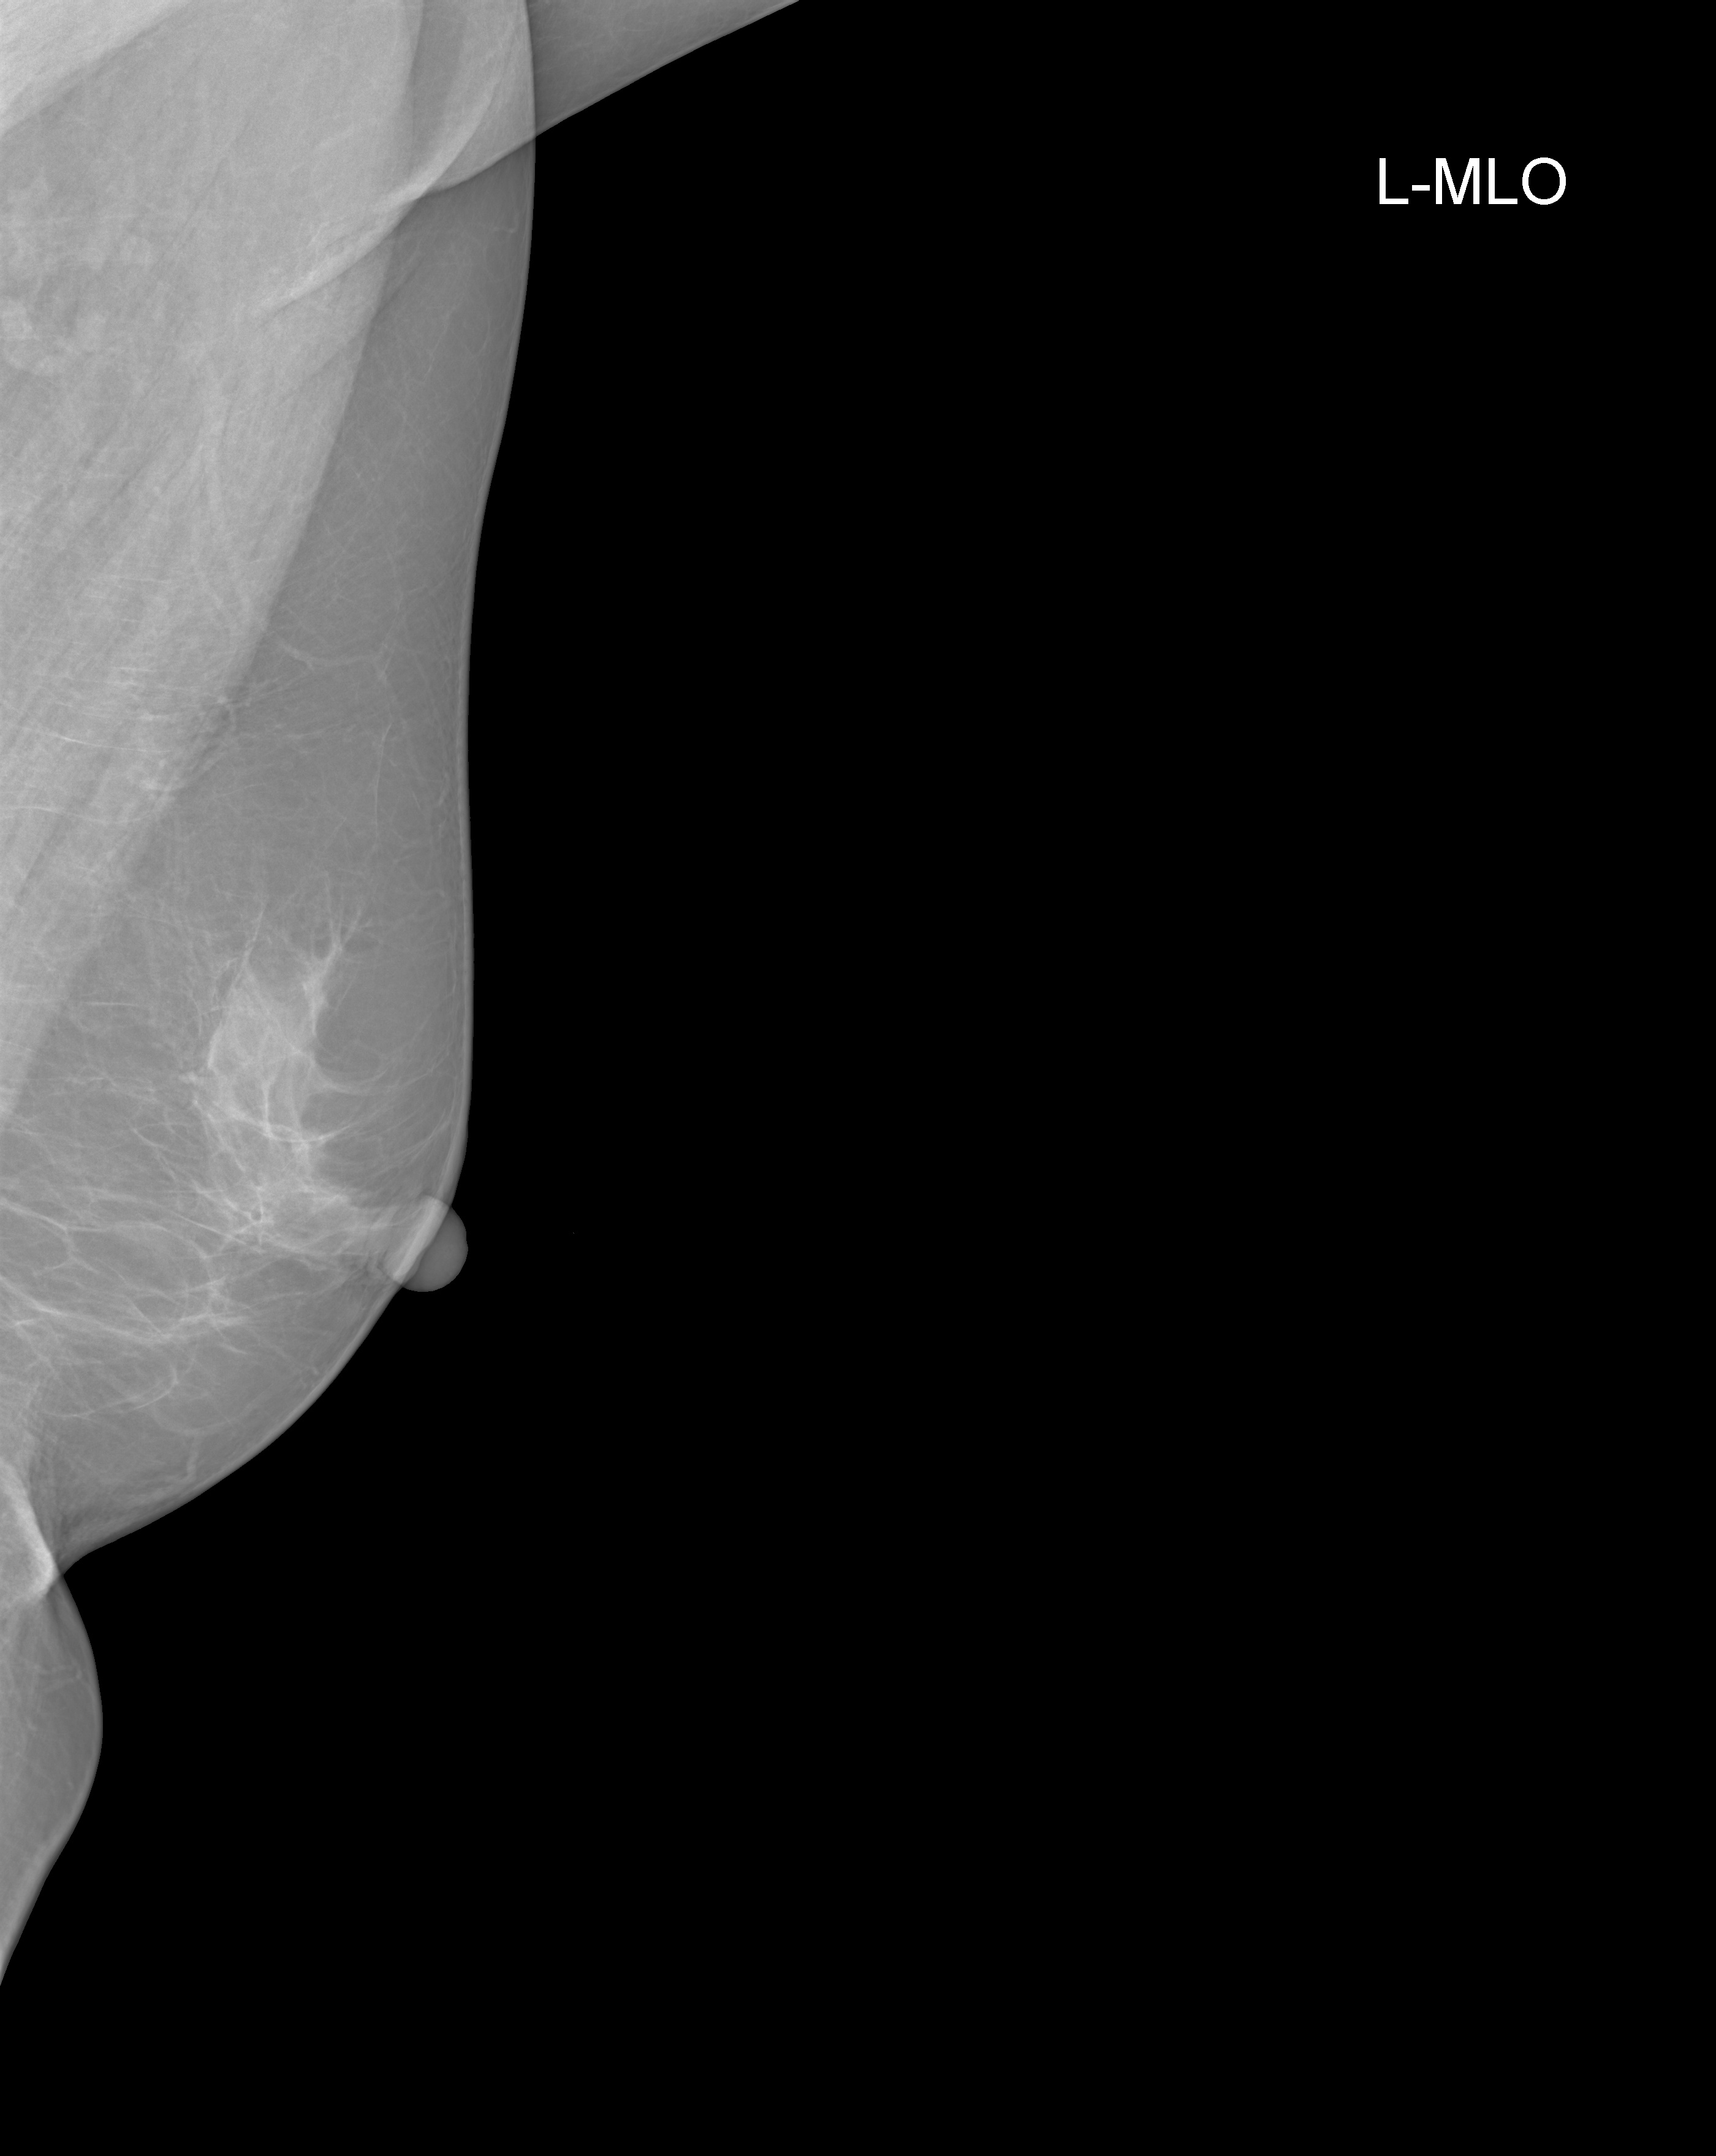

In [7]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict/20ff52d0631b27a5387abcd5920b3e5d.jpg"))


In [8]:
model.predict(
    source="/content/drive/MyDrive/yolo_data/images/test",
    save=True,
    conf=0.05
)



image 1/8 /content/drive/MyDrive/yolo_data/images/test/16e58fc1d65fa7587247e6224ee96527.png: 640x512 (no detections), 7.6ms
image 2/8 /content/drive/MyDrive/yolo_data/images/test/20ff52d0631b27a5387abcd5920b3e5d.png: 640x512 (no detections), 8.2ms
image 3/8 /content/drive/MyDrive/yolo_data/images/test/274942d5c9036c89aca0b16a36d2b076.png: 640x512 (no detections), 6.6ms
image 4/8 /content/drive/MyDrive/yolo_data/images/test/3a69cb46471f1417f099a177608cd5c1.png: 640x512 (no detections), 6.1ms
image 5/8 /content/drive/MyDrive/yolo_data/images/test/3c58c35e83a9250fc55edfb026c26374.png: 640x512 (no detections), 6.2ms
image 6/8 /content/drive/MyDrive/yolo_data/images/test/7054c1d9748e2732ca3b357a5c5a4e68.png: 640x512 (no detections), 6.2ms
image 7/8 /content/drive/MyDrive/yolo_data/images/test/774a97da43778b43720622b030af14e0.png: 640x512 (no detections), 6.3ms
image 8/8 /content/drive/MyDrive/yolo_data/images/test/e1b5c9fd358cb5992e2382e7fa0f7025.png: 640x480 (no detections), 6.9ms
Speed: 

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'lesion'}
 obb: None
 orig_img: array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [183, 183, 183],
         [186, 186, 186],
         [182, 182, 182]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [190, 190, 190],
         [184, 184, 184],
         [190, 190, 190]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [189, 189, 189],
         [187, 187, 187],
         [185, 185, 185]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [121, 121, 121],
         [123, 123, 123],
         [124, 124, 124]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [124, 124

In [9]:
import os
os.listdir("runs/detect/predict")


['20ff52d0631b27a5387abcd5920b3e5d.jpg',
 '3c58c35e83a9250fc55edfb026c26374.jpg',
 '274942d5c9036c89aca0b16a36d2b076.jpg',
 '774a97da43778b43720622b030af14e0.jpg',
 '7054c1d9748e2732ca3b357a5c5a4e68.jpg',
 '16e58fc1d65fa7587247e6224ee96527.jpg',
 '3a69cb46471f1417f099a177608cd5c1.jpg',
 'e1b5c9fd358cb5992e2382e7fa0f7025.jpg']

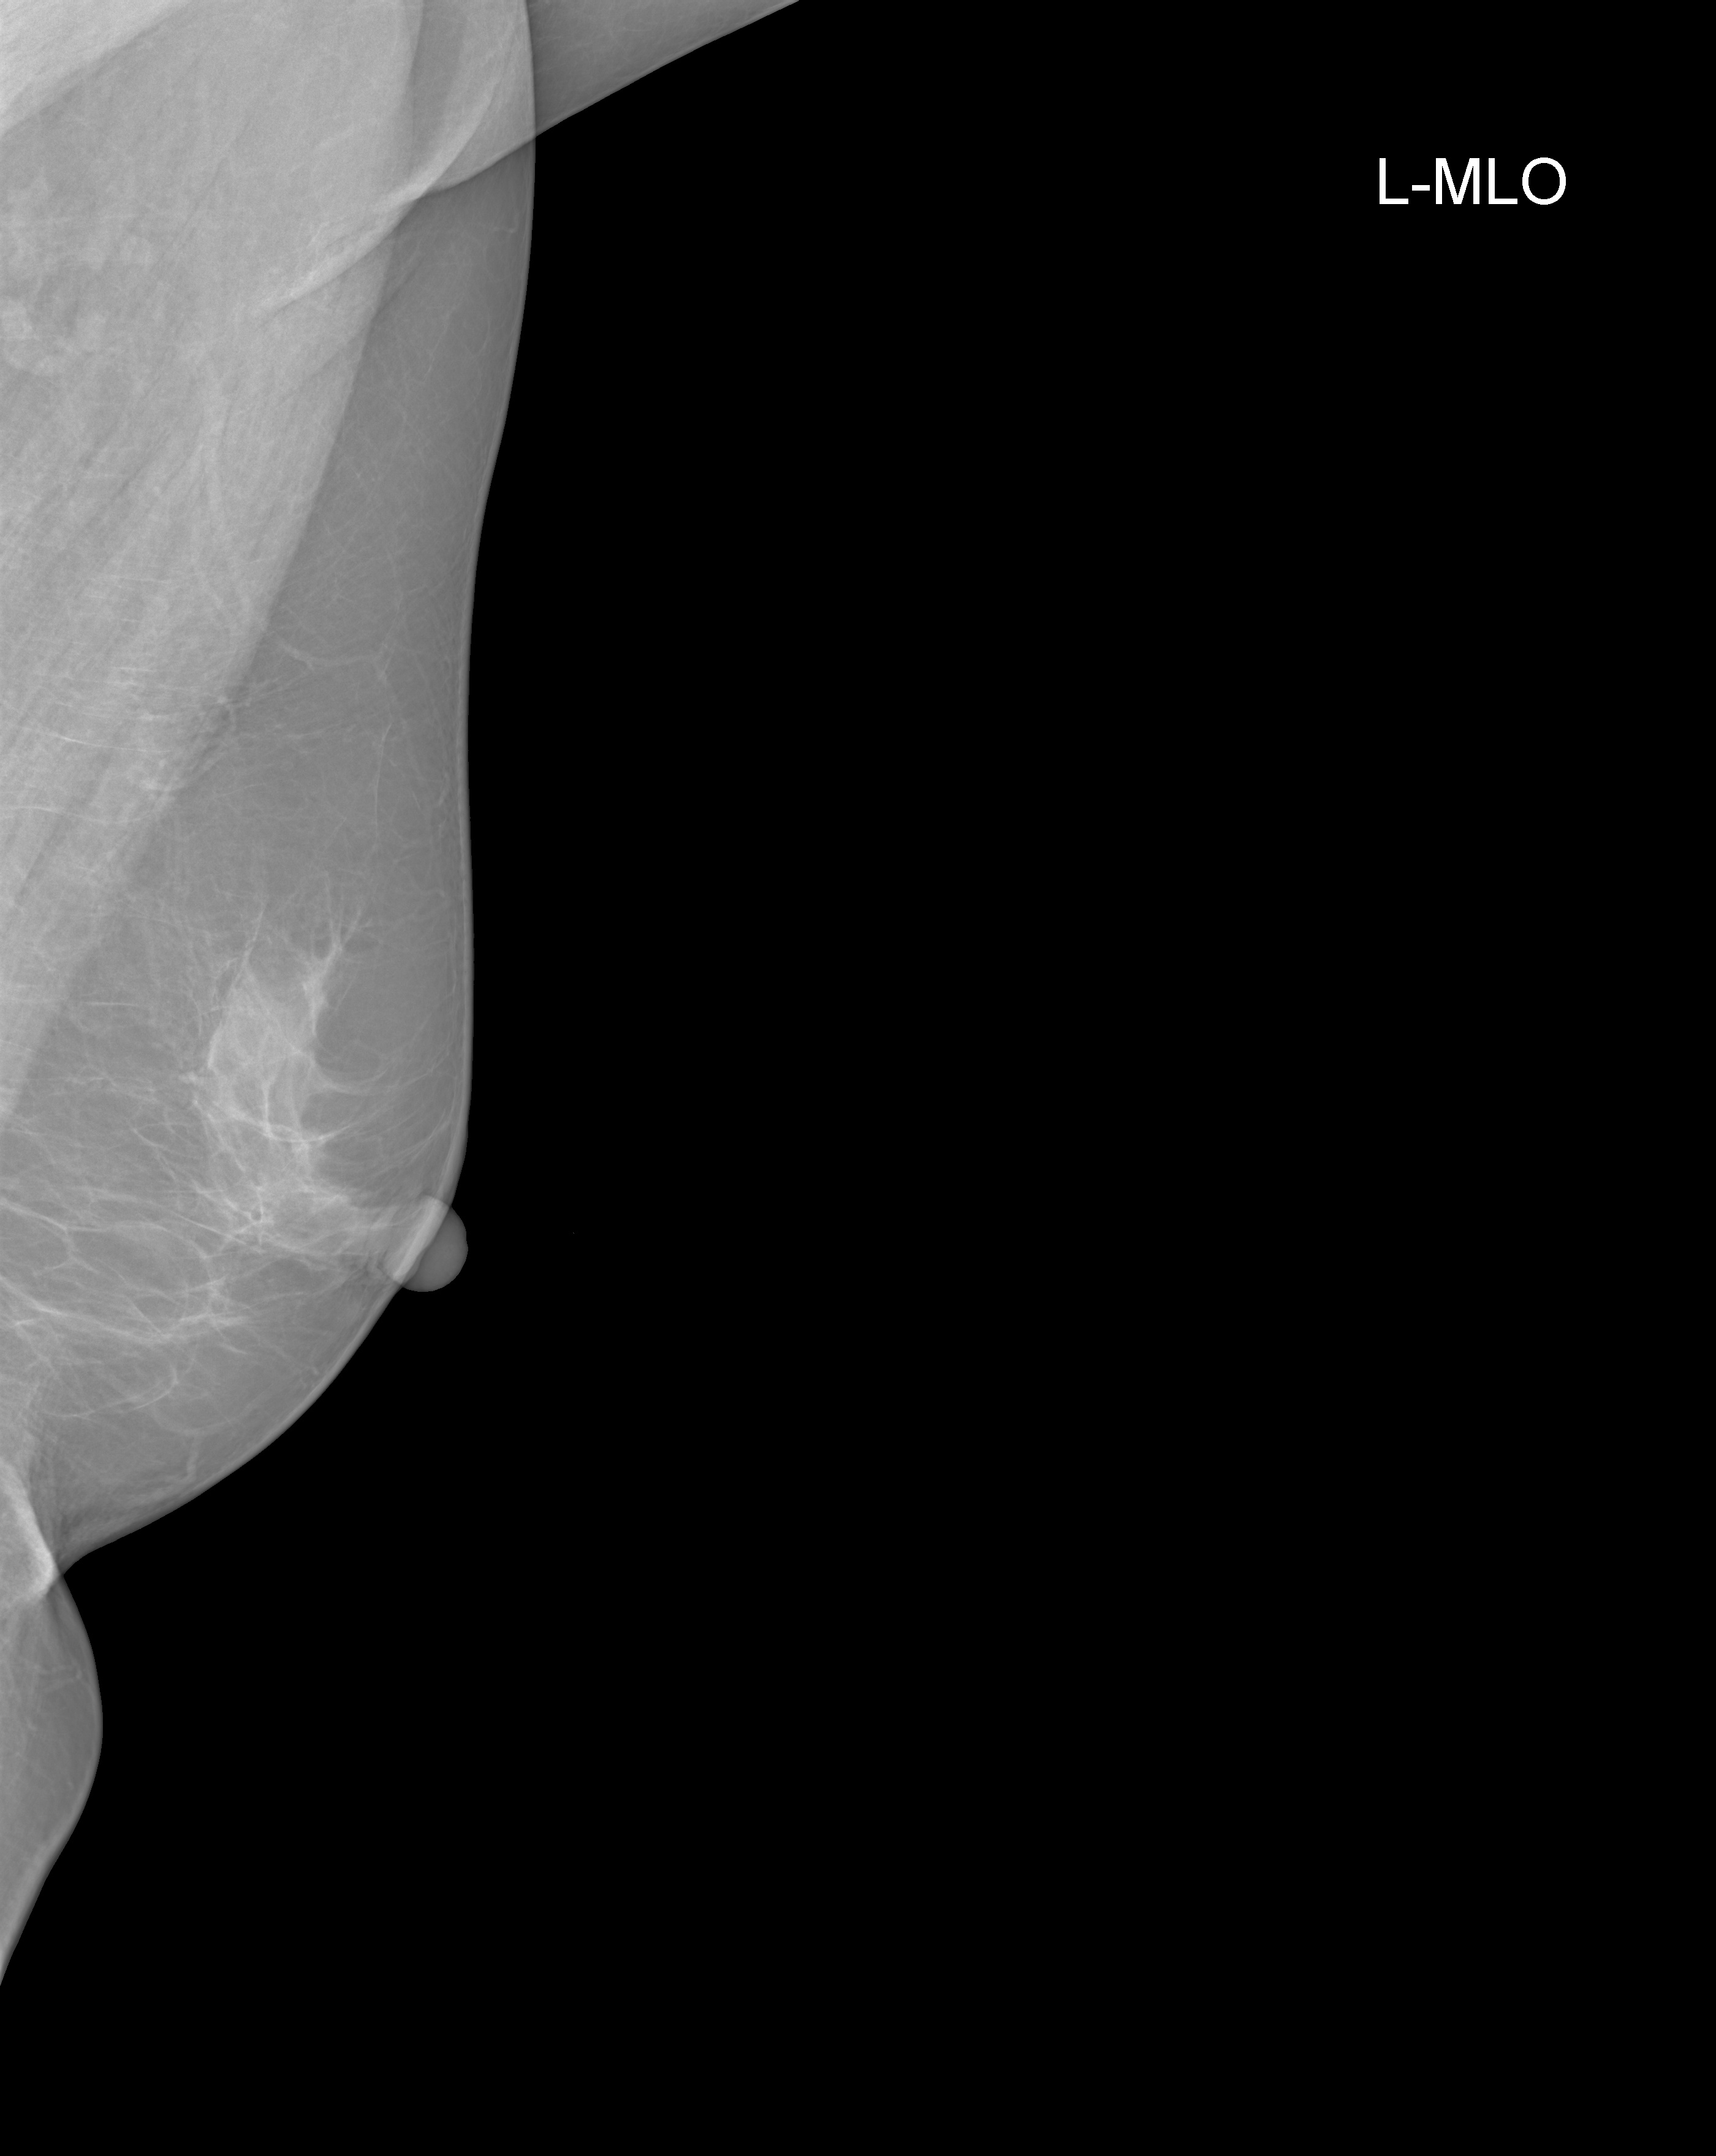

In [10]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict/20ff52d0631b27a5387abcd5920b3e5d.jpg"))

In [11]:
model.predict(
    source="/content/drive/MyDrive/yolo_data/images/test",
    save=True,
    conf=0.03
)



image 1/8 /content/drive/MyDrive/yolo_data/images/test/16e58fc1d65fa7587247e6224ee96527.png: 640x512 (no detections), 7.3ms
image 2/8 /content/drive/MyDrive/yolo_data/images/test/20ff52d0631b27a5387abcd5920b3e5d.png: 640x512 (no detections), 11.2ms
image 3/8 /content/drive/MyDrive/yolo_data/images/test/274942d5c9036c89aca0b16a36d2b076.png: 640x512 (no detections), 8.6ms
image 4/8 /content/drive/MyDrive/yolo_data/images/test/3a69cb46471f1417f099a177608cd5c1.png: 640x512 (no detections), 8.3ms
image 5/8 /content/drive/MyDrive/yolo_data/images/test/3c58c35e83a9250fc55edfb026c26374.png: 640x512 (no detections), 8.4ms
image 6/8 /content/drive/MyDrive/yolo_data/images/test/7054c1d9748e2732ca3b357a5c5a4e68.png: 640x512 (no detections), 8.1ms
image 7/8 /content/drive/MyDrive/yolo_data/images/test/774a97da43778b43720622b030af14e0.png: 640x512 (no detections), 8.0ms
image 8/8 /content/drive/MyDrive/yolo_data/images/test/e1b5c9fd358cb5992e2382e7fa0f7025.png: 640x480 (no detections), 12.0ms
Speed

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'lesion'}
 obb: None
 orig_img: array([[[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [183, 183, 183],
         [186, 186, 186],
         [182, 182, 182]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [190, 190, 190],
         [184, 184, 184],
         [190, 190, 190]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [189, 189, 189],
         [187, 187, 187],
         [185, 185, 185]],
 
        ...,
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [121, 121, 121],
         [123, 123, 123],
         [124, 124, 124]],
 
        [[  0,   0,   0],
         [  0,   0,   0],
         [  0,   0,   0],
         ...,
         [124, 124

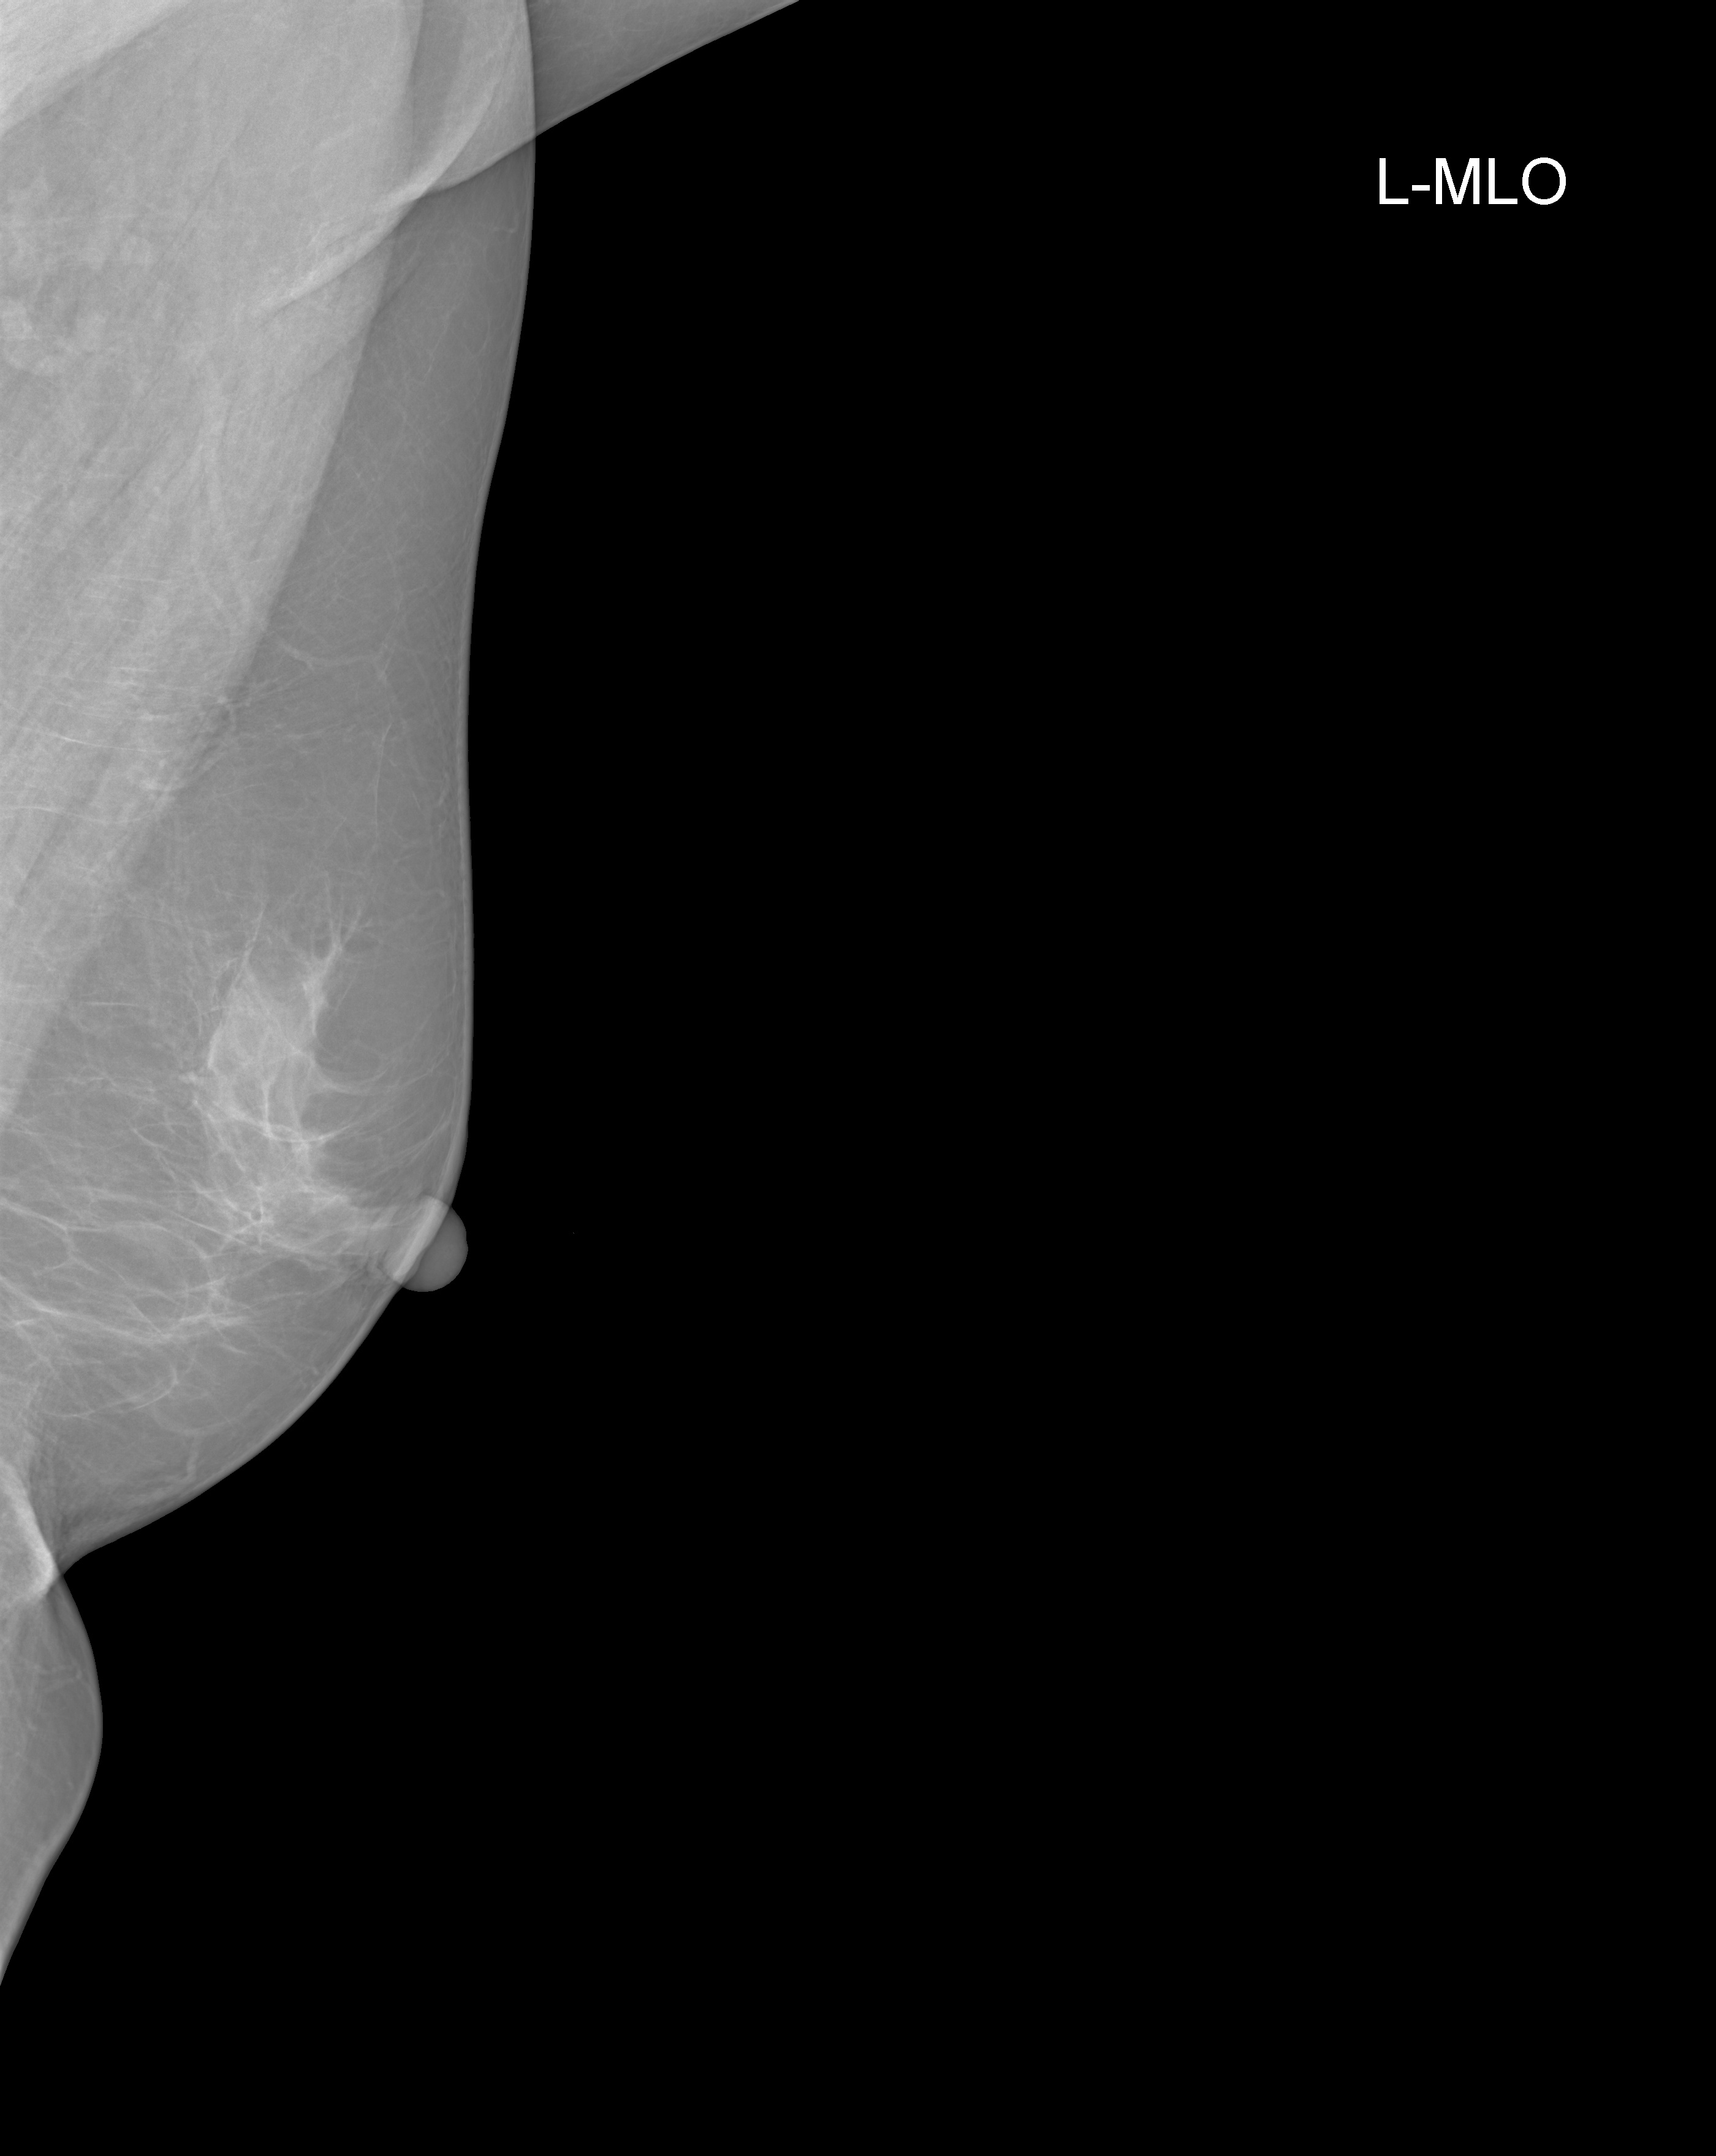

In [12]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict/20ff52d0631b27a5387abcd5920b3e5d.jpg"))

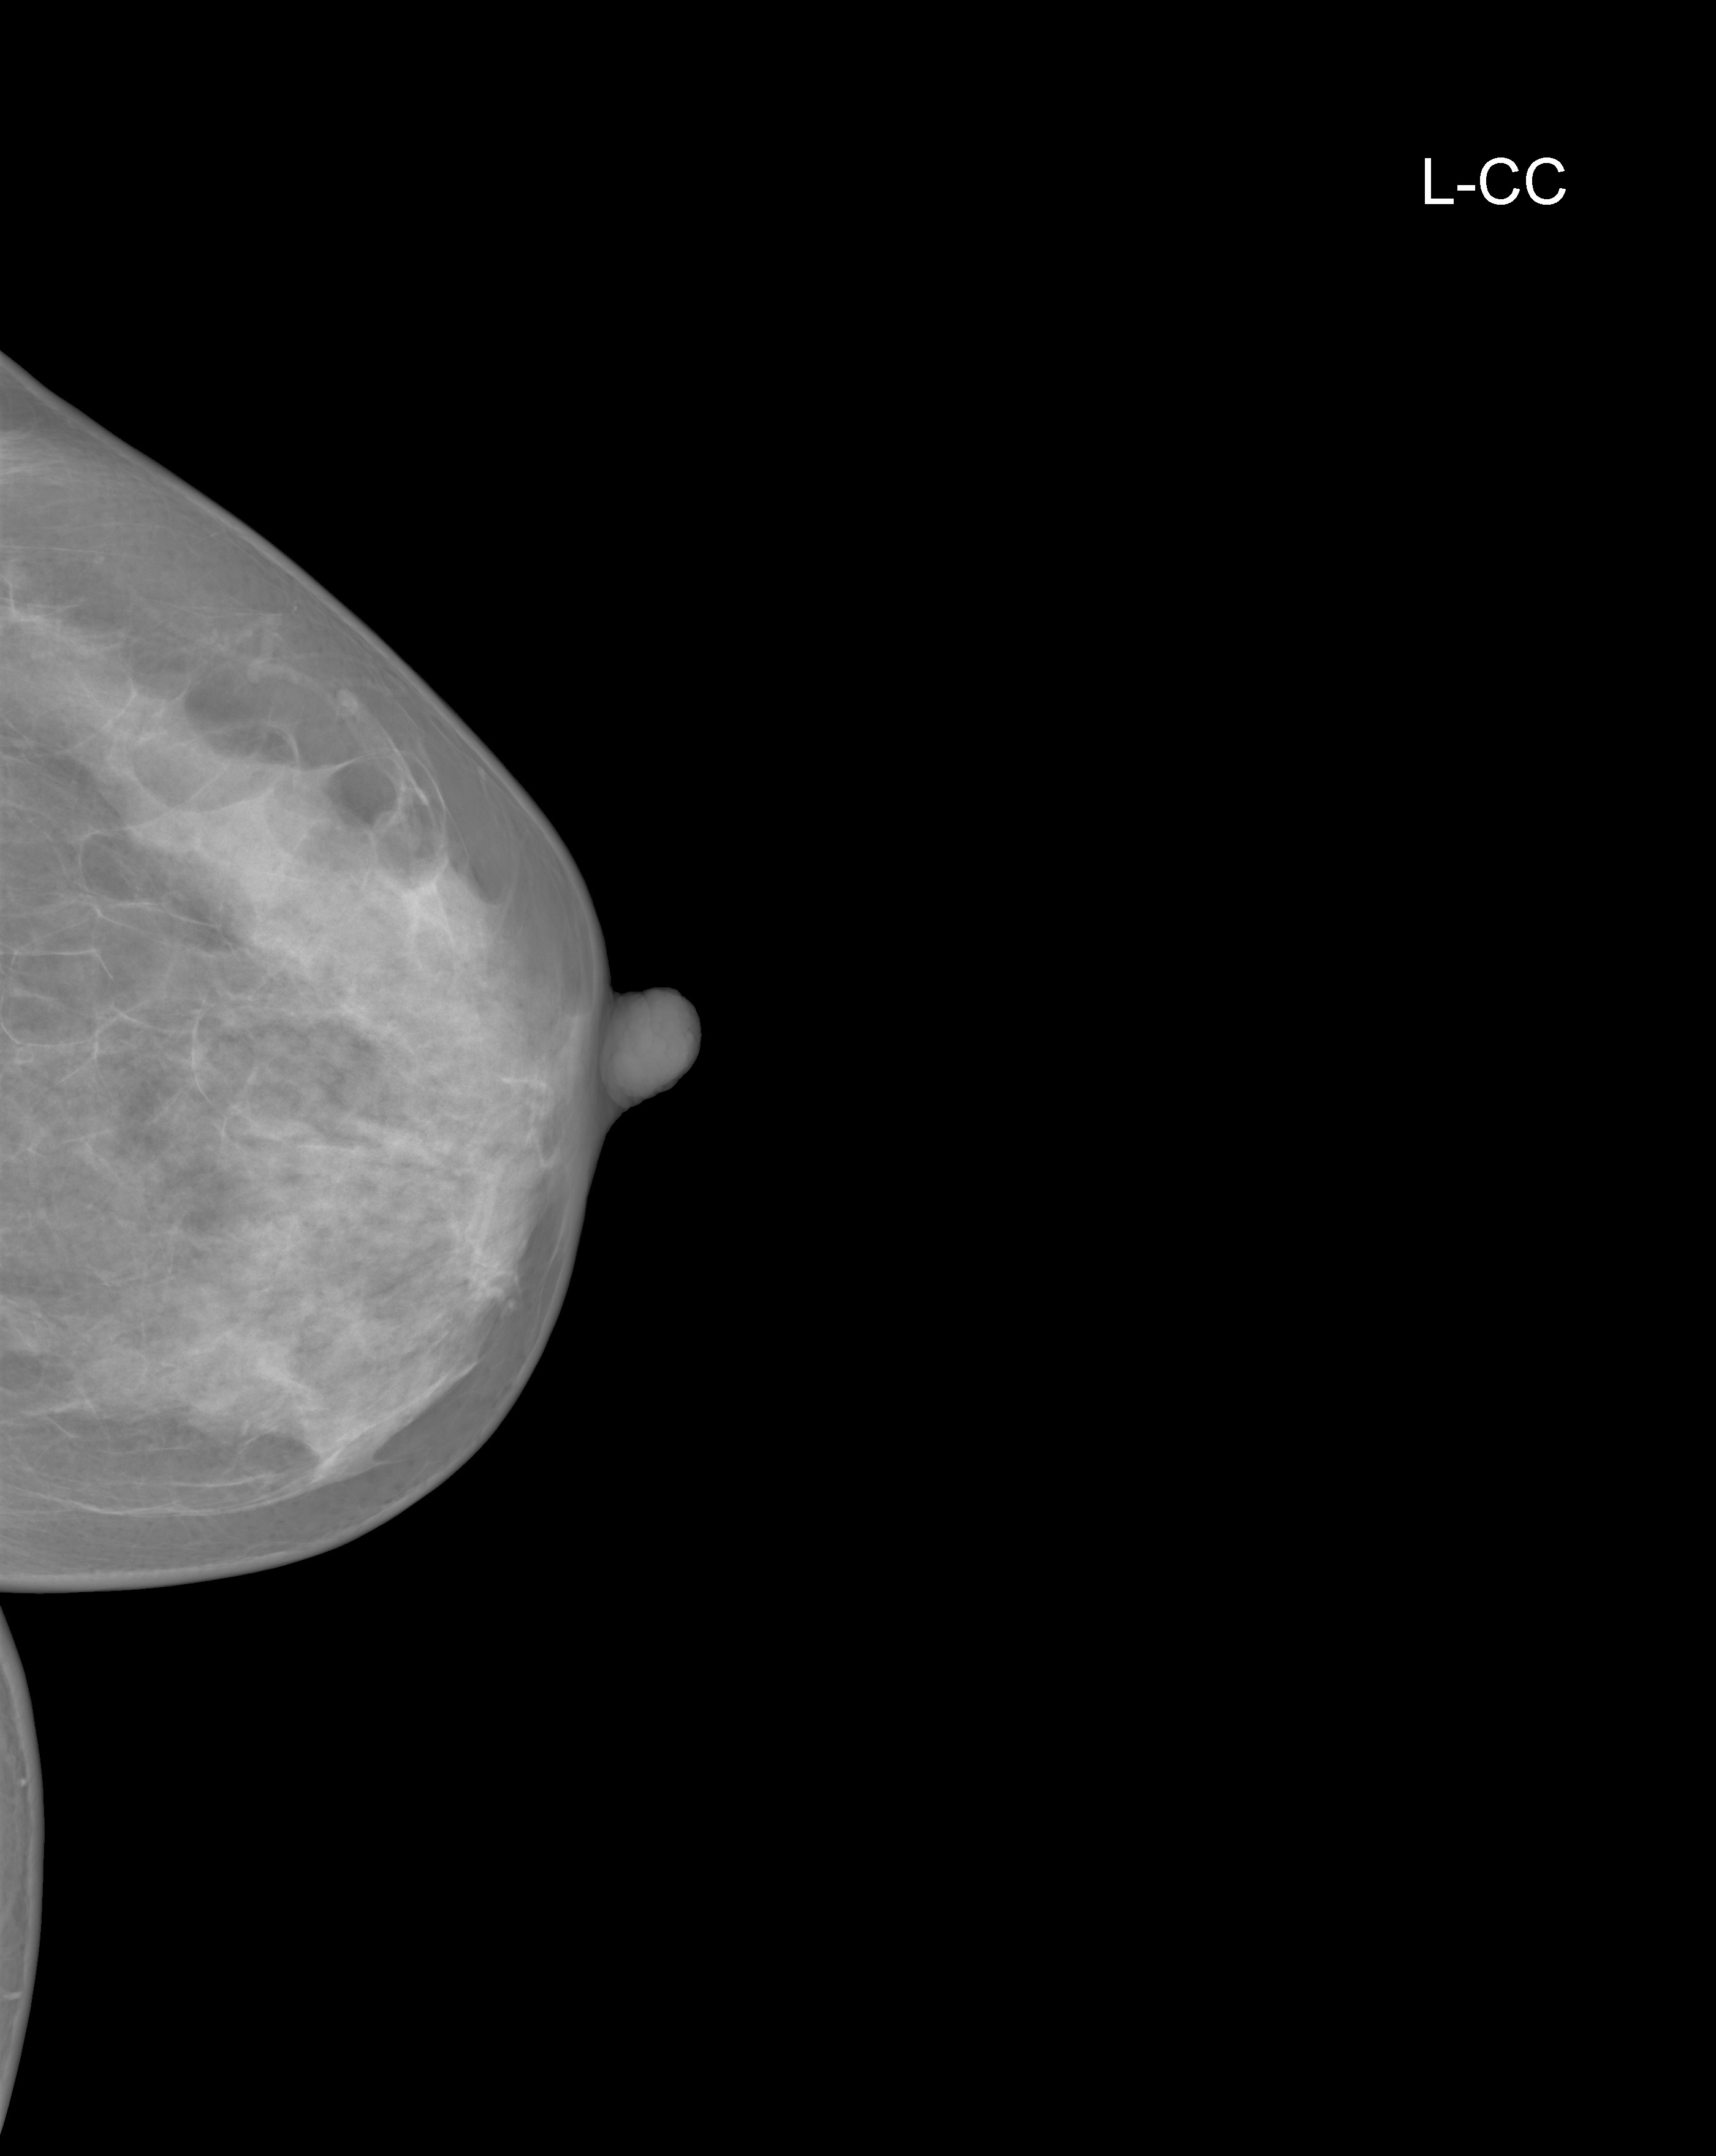

In [13]:
from IPython.display import Image, display

display(Image(filename="runs/detect/predict/3c58c35e83a9250fc55edfb026c26374.jpg"))